In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from scipy.ndimage import gaussian_filter1d
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# --- [환경 설정 구역] ---
EPOCHS = 250
BATCH_SIZE = 64
LR = 0.001
WINDOW_SIZE = 30
RUL_CAP = 125  
MY_EXCLUDE_LIST = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']

# [함수 정의]
def drop_selected_sensors(df, exclude_list):
    return df.drop(columns=[c for c in exclude_list if c in df.columns])

def add_rul_label_train(df, cap=125):
    df = df.copy()
    max_cycle = df.groupby('unit_nr')['time_cycles'].transform('max')
    df['RUL'] = (max_cycle - df['time_cycles']).clip(upper=cap)
    return df

def preprocess_sensors(train_df, test_df, alpha=2):
    sensors = [c for c in train_df.columns if c.startswith('s')]
    scaler = MinMaxScaler()
    for s in sensors:
        train_df[s] = train_df.groupby('unit_nr')[s].transform(lambda x: gaussian_filter1d(x, sigma=alpha))
        test_df[s] = test_df.groupby('unit_nr')[s].transform(lambda x: gaussian_filter1d(x, sigma=alpha))
    train_df[sensors] = scaler.fit_transform(train_df[sensors])
    test_df[sensors] = scaler.transform(test_df[sensors])
    return train_df, test_df, sensors

def make_train_windows(df, window_size, sensors):
    X, y = [], []
    for unit in df['unit_nr'].unique():
        u_df = df[df['unit_nr'] == unit]
        if len(u_df) >= window_size:
            data = u_df[sensors].values
            target = u_df['RUL'].values
            for i in range(window_size, len(u_df) + 1):
                X.append(data[i-window_size:i, :])
                y.append(target[i-1])
    return torch.FloatTensor(np.array(X)).transpose(1, 2), torch.FloatTensor(np.array(y)).view(-1, 1)

def make_test_windows_last(df, window_size, sensors):
    X_list = []
    for unit in df['unit_nr'].unique():
        u_df = df[df['unit_nr'] == unit]
        X_list.append(u_df[sensors].values[-window_size:, :])
    return torch.FloatTensor(np.array(X_list)).transpose(1, 2)

def evaluate_and_plot_results(model, X_test, y_test, title_suffix=""):
    model.eval()
    with torch.no_grad():
        preds = model(X_test).numpy().flatten()
        trues = y_test.numpy().flatten()
    rmse = np.sqrt(np.mean((preds - trues)**2))
    d = preds - trues
    score = sum([(np.exp(-i/13)-1) if i<0 else (np.exp(i/10)-1) for i in d])
    print(f"\n [{title_suffix}] Final RMSE: {rmse:.4f} | NASA Score: {score:.2f}")
    sns.set_style("darkgrid")
    df_plot = pd.DataFrame({'Actual': trues, 'Predicted': preds}).sort_values(by='Actual').reset_index(drop=True)
    plt.figure(figsize=(10, 5))
    plt.plot(df_plot['Actual'], label='Actual RUL', color='#C0504D', marker='o', markersize=3)
    plt.plot(df_plot['Predicted'], label='Predicted RUL', color='#4F81BD', marker='^', markersize=3, alpha=0.7)
    plt.title(f'Result: {title_suffix}')
    plt.legend(); plt.show()

In [7]:
df_RUL1 = pd.read_csv('../TH/CMAPSSData/RUL_FD001.csv')
df_TEST1 = pd.read_csv('../TH/CMAPSSData/test_FD001.csv')
df_TRAIN1 = pd.read_csv('../TH/CMAPSSData/train_FD001.csv')

In [8]:
train_p = drop_selected_sensors(df_TRAIN1, MY_EXCLUDE_LIST)
test_p = drop_selected_sensors(df_TEST1, MY_EXCLUDE_LIST)
train_p = add_rul_label_train(train_p, cap=RUL_CAP)
train_p, test_p, selected_sensors = preprocess_sensors(train_p, test_p)

X_tr, y_tr = make_train_windows(train_p, WINDOW_SIZE, selected_sensors)
X_te = make_test_windows_last(test_p, WINDOW_SIZE, selected_sensors)

# 에러 수정 포인트: upper=RUL_CAP -> max=RUL_CAP
y_te = torch.FloatTensor(df_RUL1.values).view(-1, 1).clip(max=RUL_CAP)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)

CNN 학습 시작 (Total Epochs: 250)
Epoch 20/250 완료
Epoch 40/250 완료
Epoch 60/250 완료
Epoch 80/250 완료
Epoch 100/250 완료
Epoch 120/250 완료
Epoch 140/250 완료
Epoch 160/250 완료
Epoch 180/250 완료
Epoch 200/250 완료
Epoch 220/250 완료
Epoch 240/250 완료

📊 [CNN (Epochs: 250)] Final RMSE: 14.2041 | NASA Score: 334.61


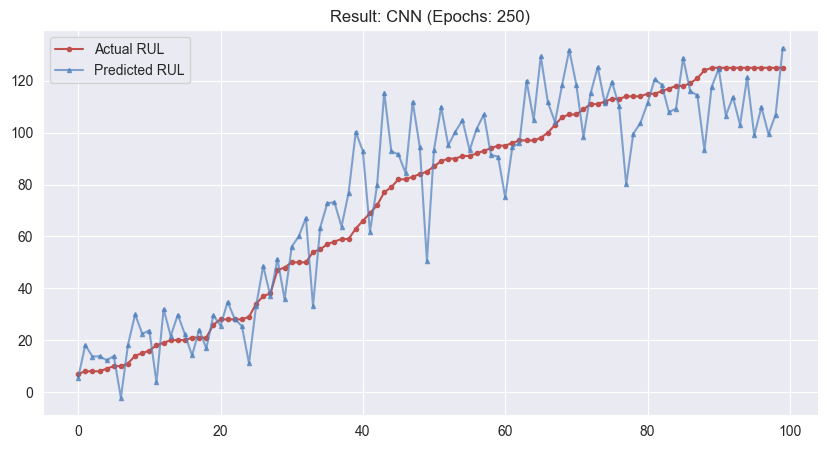

In [9]:
class CNN(nn.Module):
    def __init__(self, n_s, w_s):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_s, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2), nn.Flatten(),
            nn.Linear(32 * (w_s // 2), 1)
        )
    def forward(self, x): return self.net(x)

# 1. 모델 생성 및 설정
model_cnn = CNN(len(selected_sensors), WINDOW_SIZE)
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=LR)
criterion = nn.MSELoss()

# 2. 학습 시작
print(f"CNN 학습 시작 (Total Epochs: {EPOCHS})")
for e in range(EPOCHS):
    model_cnn.train()
    for bx, by in train_loader:
        optimizer.zero_grad()
        criterion(model_cnn(bx), by).backward()
        optimizer.step()
    if (e+1) % 20 == 0: print(f"Epoch {e+1}/{EPOCHS} 완료")

# 3. 평가 및 시각화
evaluate_and_plot_results(model_cnn, X_te, y_te, f"CNN (Epochs: {EPOCHS})")

In [11]:
!pip install mlflow

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/10.5 MB 4.4 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/10.5 MB 4.5 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/10.5 MB 4.6 MB/s eta 0:00:02
   -------------- ------------------------- 3.7/10.5 MB 4.5 MB/s eta 0:00:02
   ------------------ --------------------- 4.7/10.5 MB 4.7 MB/s eta 0:00:02
   ---------------------- ----------------- 5.8/10.5 MB 5.0 MB/s eta 0:00:01
   -------------------------- ------------- 6.8/10.5 MB 4.8 MB/s eta 0:00:01
   ----------------------------- ---------- 7.6/10.5 MB 4.7 MB/s eta 0:00:01
   ---------------------------------- ----- 8.9/10.5 MB 4.9 MB/s eta 0:00:01
   ---------------------------------------  10.2/10.5 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------- 10.5/10.5 MB 5.0 MB/s  0:00:02
   ---

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [13]:
import sys
!{sys.executable} -m pip install mlflow

  Using cached mlflow-3.11.1-py3-none-any.whl.metadata (49 kB)
  Using cached mlflow_skinny-3.11.1-py3-none-any.whl.metadata (49 kB)
  Using cached mlflow_tracing-3.11.1-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.2-py3-none-any.whl.metadata (5.3 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached huey-2.6.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached skops-0.13.0-py3-none-any.whl.metadata (5.6 kB)
  Using cached waitress-3.0.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached cachetools-7.0.5-py3-none-any.whl.metadata (5.6 kB)
  Using cached click-8.3.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached databricks_sdk-0.102.0-py3-none-any.whl.metadata (40 kB)
  Using cach


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2026/04/15 20:35:40 INFO mlflow.tracking.fluent: Experiment with name 'NASA_RUL_Project' does not exist. Creating a new experiment.


🚀 CNN_1D_Base 학습 및 MLflow 기록 시작 (Total Epochs: 250)
Epoch [10/250], Loss: 384.2158, LR: 0.001
Epoch [20/250], Loss: 196.8631, LR: 0.001
Epoch [30/250], Loss: 182.2043, LR: 0.001
Epoch [40/250], Loss: 175.1296, LR: 0.001
Epoch [50/250], Loss: 171.9301, LR: 0.001
Epoch [60/250], Loss: 169.3929, LR: 0.001
Epoch [70/250], Loss: 167.1793, LR: 0.001
Epoch [80/250], Loss: 166.2997, LR: 0.001
Epoch [90/250], Loss: 164.9680, LR: 0.001
Epoch [100/250], Loss: 166.9025, LR: 0.001
Epoch [110/250], Loss: 163.1535, LR: 0.001
Epoch [120/250], Loss: 161.9720, LR: 0.001
Epoch [130/250], Loss: 161.2530, LR: 0.001
Epoch [140/250], Loss: 161.1641, LR: 0.001
Epoch [150/250], Loss: 159.3910, LR: 0.001
Epoch [160/250], Loss: 158.9731, LR: 0.001
Epoch [170/250], Loss: 158.8882, LR: 0.001
Epoch [180/250], Loss: 157.5577, LR: 0.001
Epoch [190/250], Loss: 156.4743, LR: 0.001
Epoch [200/250], Loss: 155.9507, LR: 0.001
Epoch [210/250], Loss: 155.2443, LR: 0.001
Epoch [220/250], Loss: 154.6819, LR: 0.001
Epoch [230/

2026/04/15 20:37:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 20:37:01 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Epoch [250/250], Loss: 153.3684, LR: 0.001
✅ 학습 완료! 최종 RMSE: 14.3956

📊 [CNN (Epochs: 250)] Final RMSE: 14.3956 | NASA Score: 355.31


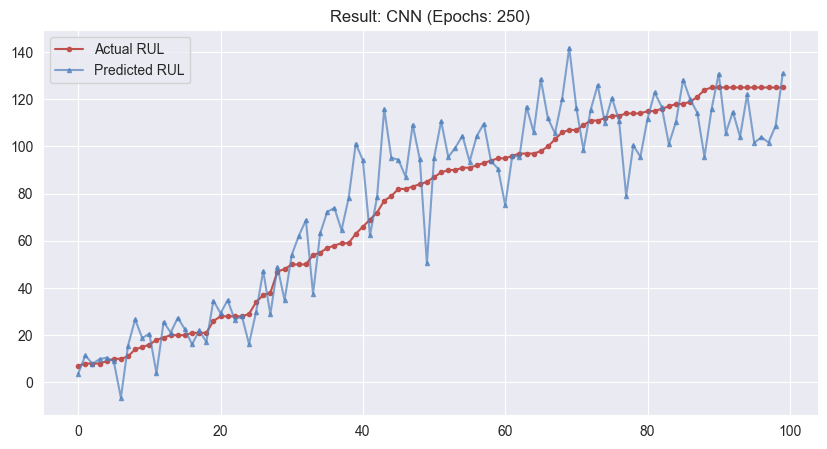

In [ ]:
import mlflow
import mlflow.pytorch
import torch
import torch.nn as nn

# 0. MLflow 실험 설정
mlflow.set_experiment("NASA_RUL_Project")

# 1. 모델 생성 및 설정 (제공해주신 CNN 구조 활용)
# selected_sensors와 WINDOW_SIZE는 환경 설정 구역의 변수를 따릅니다.
model = CNN(len(selected_sensors), WINDOW_SIZE) 
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# MLflow 실행 시작
model_variant = "CNN_1D_Base"
with mlflow.start_run(run_name=model_variant):
    # 하이퍼파라미터 기록
    mlflow.log_params({
        "model_type": "CNN",
        "epochs": EPOCHS,
        "lr": LR,
        "window_size": WINDOW_SIZE,
        "batch_size": BATCH_SIZE
    })

    print(f"🚀 {model_variant} 학습 및 MLflow 기록 시작 (Total Epochs: {EPOCHS})")

    # 2. 학습 루프
    for e in range(1, EPOCHS + 1):
        model.train() # 여기서 model_cnn이 아닌 model로 통일해야 에러가 안 납니다.
        epoch_loss = 0
        for bx, by in train_loader:
            optimizer.zero_grad()
            output = model(bx)
            loss = criterion(output, by)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        scheduler.step(avg_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # MLflow에 매 에포크 지표 기록
        mlflow.log_metric("train_loss", avg_loss, step=e)
        mlflow.log_metric("lr", current_lr, step=e)
        
        # 요청하신 로그 형식 출력
        if e % 10 == 0:
            print(f"Epoch [{e}/{EPOCHS}], Loss: {avg_loss:.4f}, LR: {current_lr}")

    # 3. 최종 평가 (엔진 100개 대상 1:1 비교)
    model.eval()
    with torch.no_grad():
        preds = model(X_te).numpy().flatten()
        trues = y_te.numpy().flatten()
    
    final_rmse = np.sqrt(np.mean((preds - trues)**2))
    mlflow.log_metric("final_rmse", final_rmse)
    
    # 모델 아티팩트 저장 (팀원 공유용)
    mlflow.pytorch.log_model(model, "model")
    
    print(f"✅ 학습 완료! 최종 RMSE: {final_rmse:.4f}")

# 4. 시각화 호출
evaluate_and_plot_results(model, X_te, y_te, f"CNN (Epochs: {EPOCHS})")